# Task 5: Exploratory Data Analysis (EDA)

**Data Analyst Internship – Elevate Labs**

**Dataset:** Titanic Dataset

**Objective:** To extract meaningful insights using statistical and visual exploration with Python, Pandas, Matplotlib, and Seaborn.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("Titanic.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Understanding the Dataset


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [7]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 2. Data Cleaning and Missing Value Handling

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)

print("Missing values handled successfully!")

Missing values handled successfully!


In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 3. Univariate Analysis

### 3.1 Age Distribution

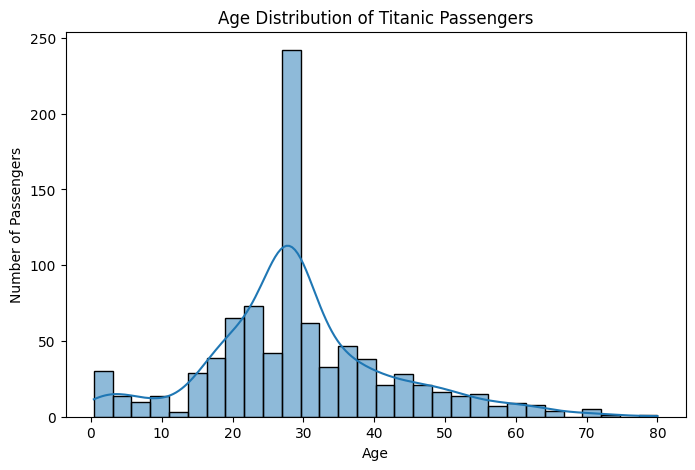

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

**Observation:** Most passengers were between 20 and 40 years old. The age distribution is slightly right-skewed, with fewer elderly passengers. The prominent peak around age 28 is partly due to missing age values being filled with the median age.

### 3.2 Fare Distribution and Outliers

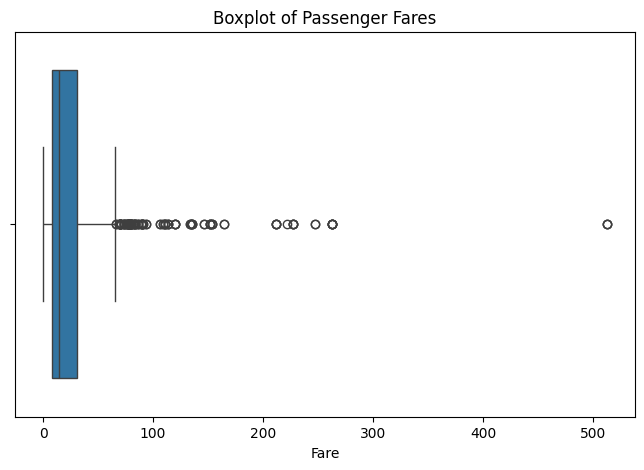

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'])

plt.title('Boxplot of Passenger Fares')
plt.xlabel('Fare')

plt.show()

**Observation:** Most passengers paid relatively low fares, while several high-fare outliers are present. The fare distribution is strongly right-skewed, with the highest fare reaching about 512.

## 4. Bivariate Analysis

### 4.1 Survival by Gender

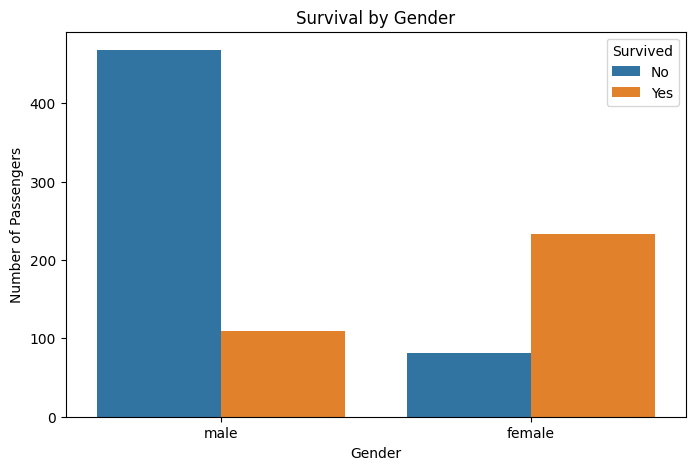

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

**Observation:** Female passengers had a much higher survival rate than male passengers. Most male passengers did not survive, while the majority of female passengers survived, showing a strong relationship between gender and survival.

### 4.2 Survival by Passenger Class

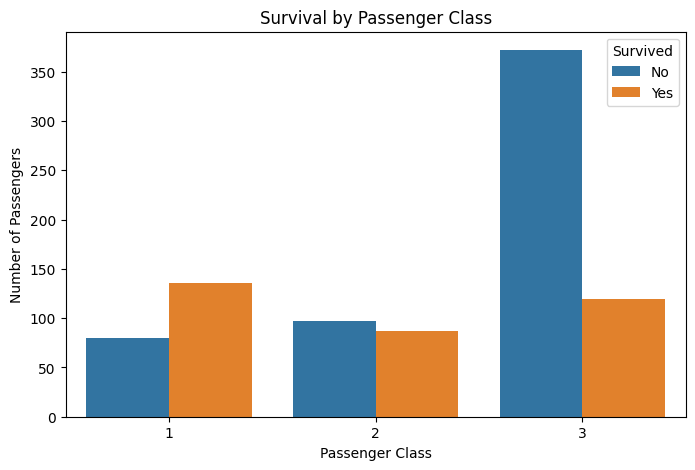

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

**Observation:** First-class passengers had a higher chance of survival, while third-class passengers experienced the highest number of deaths. This indicates a strong relationship between passenger class and survival.

### 4.3 Age vs Fare

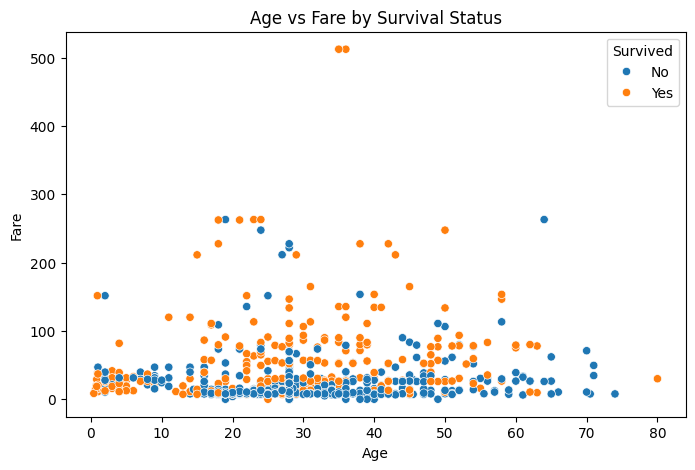

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')

plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['No', 'Yes'], title='Survived')

plt.show()

Observation: There is no strong direct relationship between age and fare. However, passengers who paid higher fares appear more frequently among survivors, suggesting that fare and passenger class had an influence on survival.

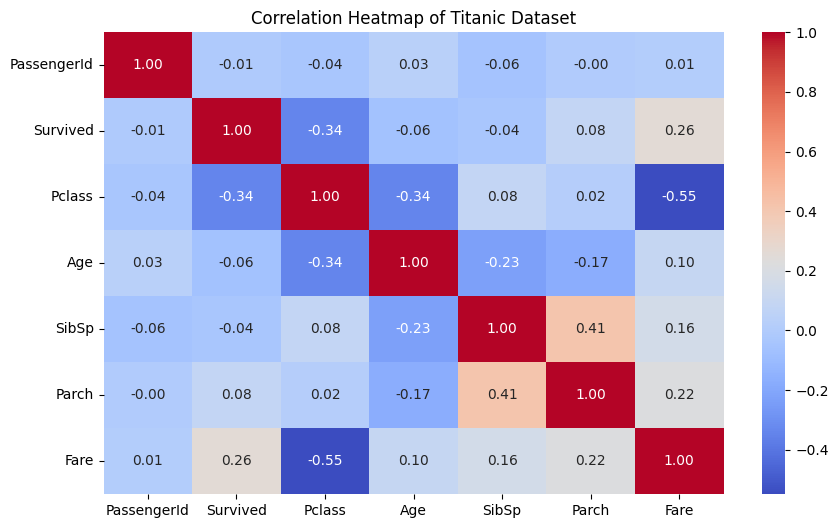

In [17]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Titanic Dataset')
plt.show()

Observation: Passenger class has a negative correlation with survival (-0.34), meaning first-class passengers were more likely to survive. Fare has a positive correlation with survival (0.26), while passenger class and fare have a strong negative correlation (-0.55). Age shows only a weak relationship with survival.

In [18]:
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100

print("Survival Rate by Gender (%):")
print(survival_by_gender)

Survival Rate by Gender (%):
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [19]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100

print("Survival Rate by Passenger Class (%):")
print(survival_by_class)

Survival Rate by Passenger Class (%):
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [20]:
overall_survival_rate = df['Survived'].mean() * 100

print(f"Overall Survival Rate: {overall_survival_rate:.2f}%")

Overall Survival Rate: 38.38%


## 5. Key Insights and Observations

- The overall survival rate was **38.38%**, meaning most passengers did not survive.
- Female passengers had a much higher survival rate (**74.20%**) than male passengers (**18.89%**).
- Passenger class strongly influenced survival. First-class passengers had the highest survival rate (**62.96%**), while third-class passengers had the lowest (**24.24%**).
- Most passengers were between **20 and 40 years old**.
- Passenger fares contained several high-value outliers, showing a large difference in ticket prices.
- Higher fares showed a positive relationship with survival, while third-class passengers had lower survival rates.
- Gender and passenger class were the strongest factors associated with survival in this analysis.

## 6. Pairplot Analysis

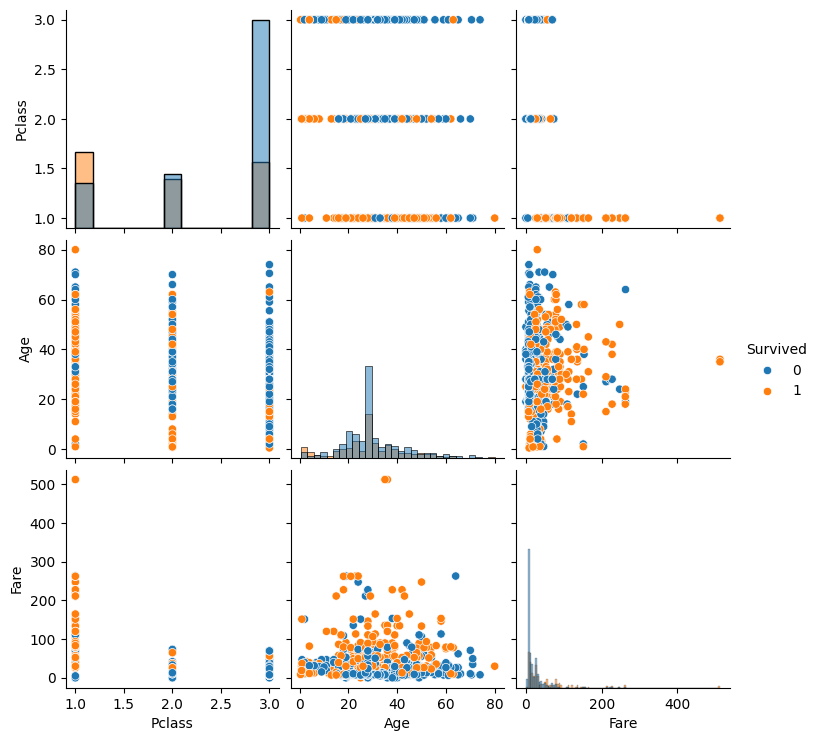

In [21]:
sns.pairplot(
    df[['Survived', 'Pclass', 'Age', 'Fare']],
    hue='Survived',
    diag_kind='hist'
)

plt.show()

### Pairplot Observation

- First-class passengers show a higher proportion of survivors compared to third-class passengers.
- Survivors are more frequently associated with higher fares.
- Most passengers were between 20 and 40 years old.
- The pairplot confirms that passenger class and fare were important factors associated with survival.